# 1. Definicija problema i ciljevi projekta
1. Definicija problema:
Rano otkrivanje i prevencija dijabetesa su od ključnog značaja za zdravlje pojedinca. Medjutim, tradicionalni nacini dijagnostike mogu biti invazivni, vremenski zahtevni i skupi. Stoga se postavlja pitanje: Da li je moguće, na osnovu lako dostupnih zdravstvenih i demografskih podataka, precizno predvideti da li će kod osobe doći do pojave dijabetesa?

Ovaj projekat ima za cilj da odgovori na to pitanje razvojem modela masinskog učenja koji će, na osnovu unosa odredjenih faktora rizika, proceniti verovatnoću da je osoba obolela od dijabetesa.

# Ciljevi projekta
Identifikacija ključnih faktora rizika: Analizirati dostupne podatke kako bi se utvrdilo koji faktori (npr. indeks telesne mase - BMI, starost, nivo glukoze u krvi, krvni pritisak) imaju najveci uticaj na razvoj dijabetesa.

Izgradnja modela masinskog ucenja: Razviti i istrenirati klasifikacioni model koji moze da klasifikuje pacijente u dve grupe: one sa dijabetesom i one bez dijabetesa, na osnovu njihovih ulaznih parametara.

# Očekivani rezultat:
Funkcionalan model mašinskog učenja koji može da, sa odredjenom tacnoscu, predvidi verovatnocu postojanja dijabetesa na osnovu unetih zdravstvenih podataka. Model bi mogao posluziti kao alat za podrsku lekarima u ranom otkrivanju ovog metabolickog poremecaja


# 2. Prikupljanje podataka
Opis skupa podataka:

Dataset: diabetes.csv (Pima Indians Diabetes Database).

Sadržaj: Skup podataka sadrži medicinske i demografske podatke za 768 žena, sa ciljem predviđanja da li će se kod pacijentkinje razviti dijabetes u roku od 5 godina od trenutka prikupljanja podataka.

Struktura podataka:

Numerički podaci (ulazne promenljive):

Pregnancies: Broj trudnoća.

Glucose: Koncentracija glukoze u plazmi nakon 2 sata u oralnom testu tolerancije glukoze.

BloodPressure: Dijastolički krvni pritisak .

SkinThickness: Debljina kožnog nabora na tricepsu .

Insulin: Nivo insulina u serumu nakon 2 sata .

BMI: Indeks telesne mase .

DiabetesPedigreeFunction: Funkcija koja procenjuje verovatnoću pojave dijabetesa na osnovu porodične istorije.

Age: Starost.

Kategorički podaci (ciljna promenljiva):

Outcome: Ciljna promenljiva. 0 znači da pacijent nema dijabetes, a 1 da ima dijabetes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [ ]:
ins = pd.read_csv("diabetes.csv")

In [ ]:
ins.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
feature_col_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

In [ ]:
X = ins[feature_col_names]
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
X.shape

(768, 8)

In [ ]:
target_col_name = ["Outcome"]

In [ ]:
y = ins[target_col_name]
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [ ]:
br_redova= len(ins)

br_redova

768

In [ ]:
ins.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<Figure size 1000x800 with 0 Axes>

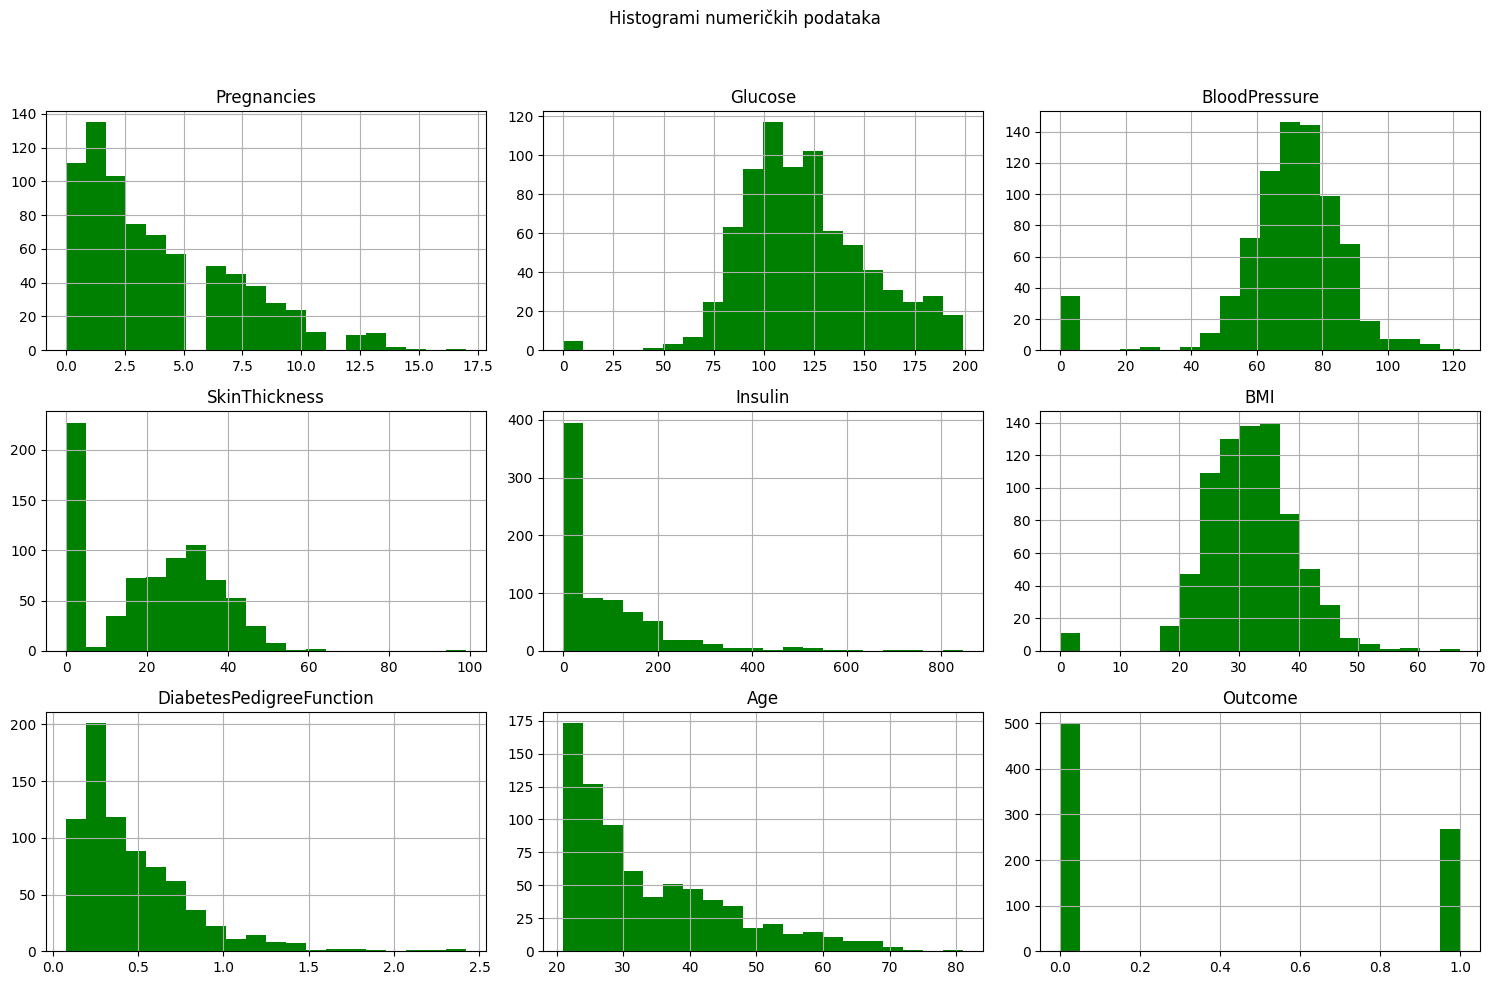

In [ ]:
plt.figure(figsize = (10, 8))
ins.hist(bins = 20, figsize = (15, 10), color ='green')
plt.suptitle('Histogrami numeričkih podataka')
plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.show()

<Axes: xlabel='Outcome', ylabel='Age'>

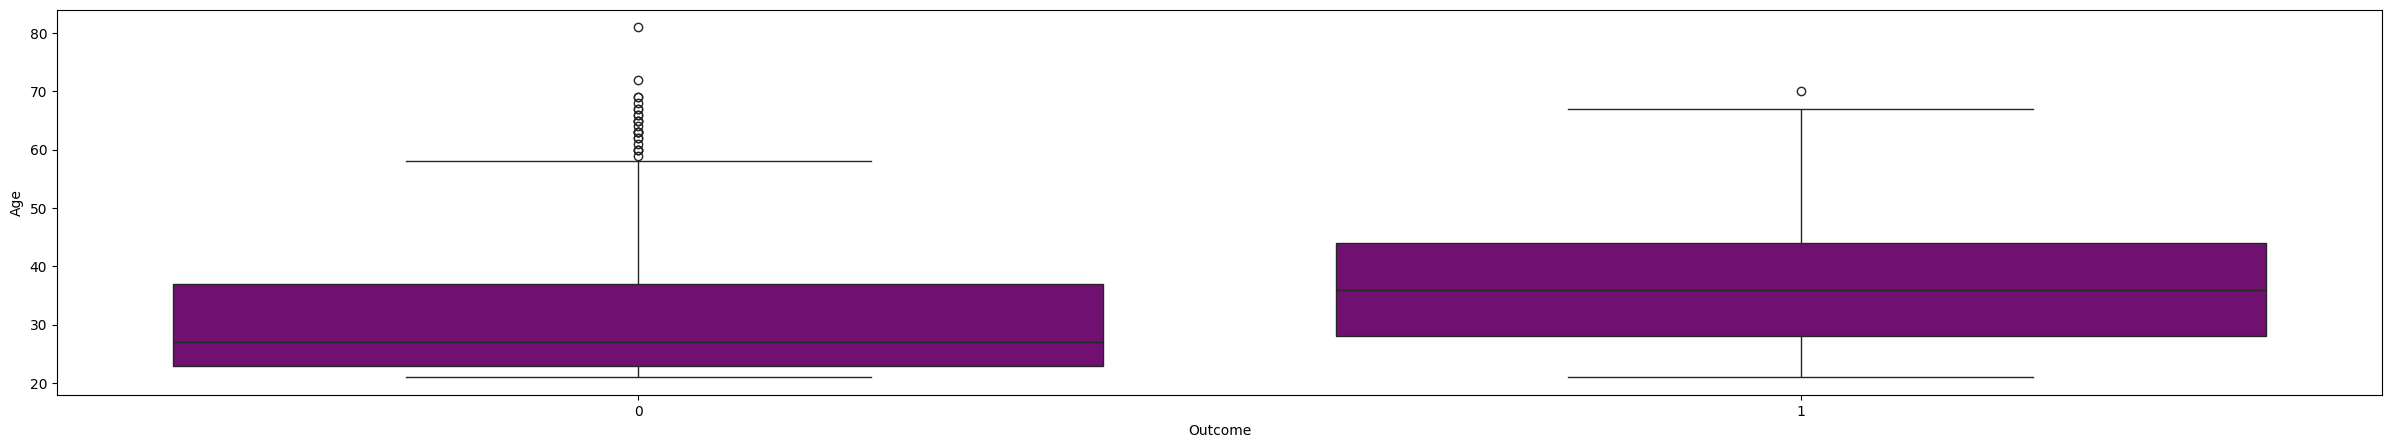

In [ ]:
plt.figure(figsize = (30,5))
sns.boxplot(data= ins, x='Outcome', y = 'Age', color='purple' )

In [ ]:
numeric_df = ins.select_dtypes(include = [np.number])
corr_matrix = numeric_df.corr()

print(corr_matrix)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

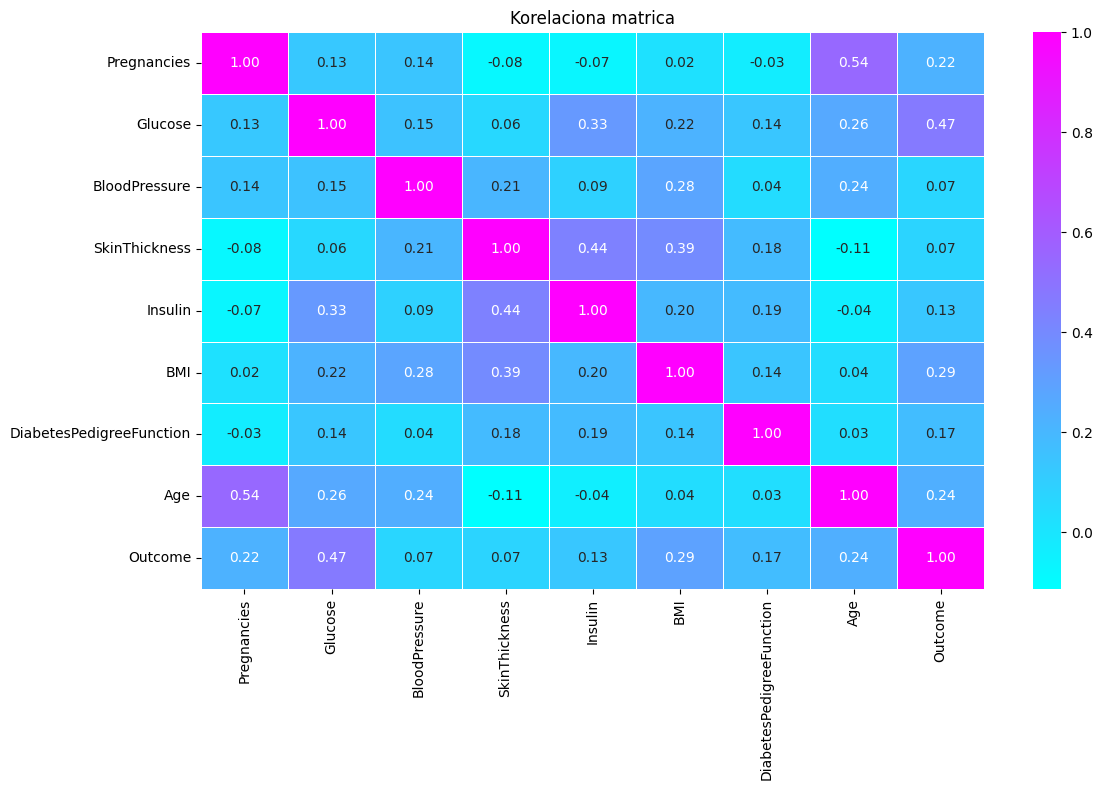

In [ ]:
plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'cool', linewidth = 0.5)
plt.title("Korelaciona matrica")
plt.tight_layout()

In [ ]:
mean = X.mean(axis=0)
std = X.std(axis=0)
X_scaled = (X - mean) / std #standardizacija

In [ ]:
# polinomske karakteristike stepena 2
X_poly = np.hstack((X_scaled, X_scaled**2))

print(X_poly.shape)

(768, 16)


In [ ]:

X_poly_manual = np.hstack((X_scaled, X_scaled**2))

# Sklearn pristup:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_sklearn = poly2.fit_transform(X_scaled)

print(f"Ručno: {X_poly_manual.shape}")
print(f"Sklearn: {X_poly_sklearn.shape}")

Ručno: (768, 16)
Sklearn: (768, 44)


In [ ]:
# dodavanje kolone jedinica
m = X_poly.shape[0]
X_b = np.c_[np.ones((m, 1)), X_poly]

In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_b, y, test_size=0.2, random_state=42)

4. Funkcija greške (MSE)


In [ ]:
def compute_mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

Gradijentni spust

m=m−α⋅ ∂m/∂J
​

gradient: ∂θ∂J​=1/m*​X^T*(ypred​−y)

In [ ]:
import numpy as np

def gradient_descent(X, y, learning_rate=0.001, epochs=1000):

    X = np.asarray(X)
    y = np.asarray(y).flatten()

    m, n = X.shape
    theta = np.random.randn(n)
    errors = []

    for epoch in range(epochs):
        y_pred = X.dot(theta)
        error = y_pred - y
        cost = (1/(2*m)) * np.dot(error.T, error) #mse
        errors.append(cost)

        gradient = (1/m) * X.T.dot(error)
        theta -= learning_rate * gradient



    return theta, errors


In [ ]:
print(X_b.shape)

(768, 17)


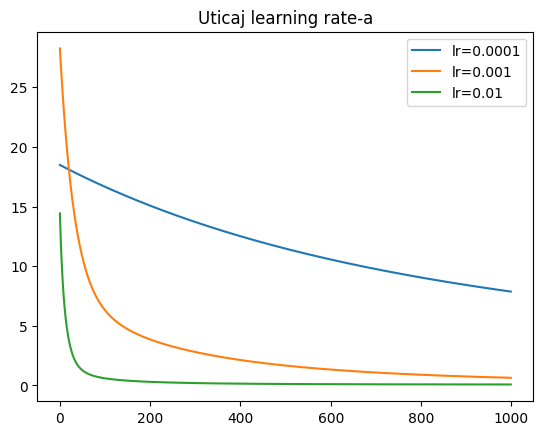

In [ ]:
lrs = [0.0001, 0.001, 0.01]

for lr in lrs:
    _, errors = gradient_descent(X_b, y, learning_rate=lr, epochs=1000)
    plt.plot(errors, label=f"lr={lr}")

plt.legend()
plt.title("Uticaj learning rate-a")
plt.show()

In [ ]:
# degree 1 vs degree 2
X_poly1 = X_scaled
X_poly2 = np.hstack((X_scaled, X_scaled**2))

In [ ]:
print("ovo je bez stepena 2", X_poly1)
print("ovo je sa stepenom 2", X_poly2)

ovo je bez stepena 2      Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.639530  0.847771       0.149543       0.906679 -0.692439  0.203880   
1      -0.844335 -1.122665      -0.160441       0.530556 -0.692439 -0.683976   
2       1.233077  1.942458      -0.263769      -1.287373 -0.692439 -1.102537   
3      -0.844335 -0.997558      -0.160441       0.154433  0.123221 -0.493721   
4      -1.141108  0.503727      -1.503707       0.906679  0.765337  1.408828   
..           ...       ...            ...            ...       ...       ...   
763     1.826623 -0.622237       0.356200       1.721613  0.869464  0.115094   
764    -0.547562  0.034575       0.046215       0.405181 -0.692439  0.609757   
765     0.342757  0.003299       0.149543       0.154433  0.279412 -0.734711   
766    -0.844335  0.159683      -0.470426      -1.287373 -0.692439 -0.240048   
767    -0.844335 -0.872451       0.046215       0.655930 -0.692439 -0.201997   

     DiabetesPedig

treniranje modela

In [ ]:
theta, errors = gradient_descent(X_b, y, learning_rate=0.001, epochs=1000)

print(theta)

[-0.10108963  0.98513745  0.28879738  0.19819477  0.6571407   0.16567548
  0.22035955  0.4361234  -1.36074093 -0.25311612  0.08894633  0.19428337
 -0.12520764 -0.09144781 -0.01673305 -0.09825585  0.69219056]


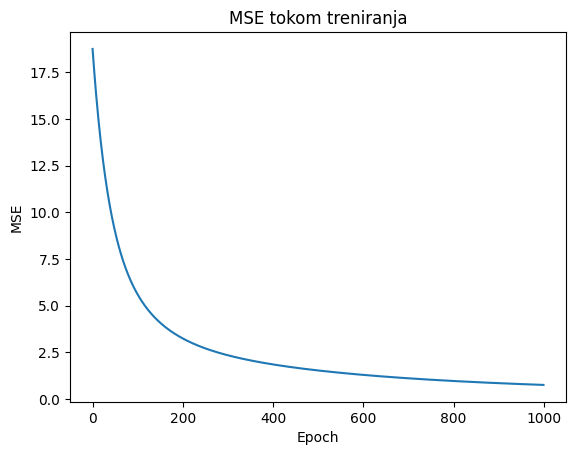

In [ ]:
plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE tokom treniranja")
plt.show()

#2.Klasifikacija i logisticka regresija

In [ ]:
def polynomial_features(X, degree=3):

    X_poly3 = X.copy()

    for d in range(2, degree+1):
        X_poly3 = np.concatenate((X_poly3, X**d), axis=1)

    return X_poly

X_poly3 = polynomial_features(X, 3)

print(X_poly.shape)

(768, 16)


In [ ]:
X_mean = X_poly.mean(axis=0)
X_std = X_poly.std(axis=0)

X_poly3 = (X_poly3 - X_mean) / X_std

In [ ]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_poly3, y, test_size=0.2, random_state=42)

Sigmoid funkcija

σ(z)=1/1+e−z

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Binary Cross Entropy (funkcija greške)

In [ ]:
def compute_loss(y, y_pred):

    epsilon = 1e-9

    loss = -np.mean(
        y*np.log(y_pred+epsilon) + (1-y)*np.log(1-y_pred+epsilon)
    )

    return loss

In [ ]:
def train_logistic_regression(X, y, lr=0.01, epochs=1000, lambda_reg=0):
  #numpy
    X = np.asarray(X)
    y = np.asarray(y).flatten()

    n_samples, n_features = X.shape


    weights = np.zeros(n_features)
    bias = 0
    losses = []

    for epoch in range(epochs):

        z = np.dot(X, weights) + bias

        # sigmoid
        y_pred = sigmoid(z)

        #L2 regularizacija
        loss = compute_loss(y, y_pred) + lambda_reg * np.sum(weights**2)
        losses.append(loss)

        #gradijenti
        dw = (1/n_samples) * np.dot(X.T, (y_pred - y)) + 2 * lambda_reg * weights
        db = (1/n_samples) * np.sum(y_pred - y)


        weights -= lr * dw
        bias -= lr * db

    return weights, bias, losses


In [ ]:
y_pred_proba = sigmoid(np.dot(X_poly3, weights) + bias)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

treniranje

In [ ]:
weights, bias, losses = train_logistic_regression(
    X_train_clf, y_train_clf,
    lr=0.01,
    epochs=1000,
    lambda_reg=0.01
)

In [ ]:
y_true = y.values

accuracy = np.mean(y_pred == y_true)
print("accuracy:", accuracy )

accuracy: 0.5680474175347222


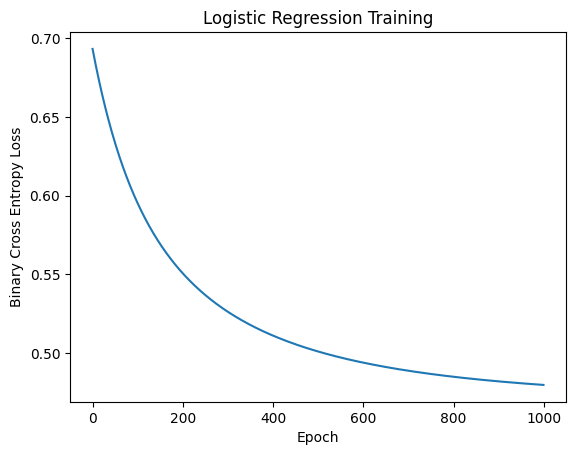

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Logistic Regression Training")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
print(cm)

[[442  58]
 [115 153]]


In [ ]:
def predict(X, weights, bias):

    z = np.dot(X, weights) + bias
    probs = sigmoid(z)

    return (probs >= 0.5).astype(int)

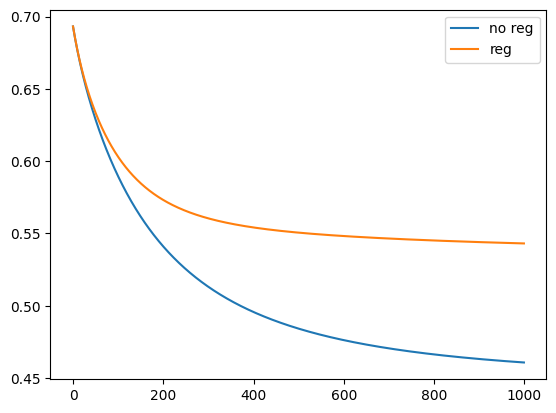

In [ ]:
weights1, bias1, losses1 = train_logistic_regression(X_poly, y, lambda_reg=0)
weights2, bias2, losses2 = train_logistic_regression(X_poly, y, lambda_reg=0.1)

plt.plot(losses1, label="no reg")
plt.plot(losses2, label="reg")
plt.legend()
plt.show()

In [ ]:

def polynomial_features(X, degree=3):
    X_poly = X.copy()
    for d in range(2, degree+1):
        X_poly = np.concatenate((X_poly, X**d), axis=1)
    return X_poly

# Sklearn pristup
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_sklearn = poly3.fit_transform(X_scaled)

print(f"Sklearn stepen 3: {X_poly_sklearn.shape}")

Sklearn stepen 3: (768, 164)


Odgovori na pitanja, 1 deo:

1. Polinomske karakteristike (kao što su x₁², x₂², x₁*x₂) omogucavaju linearnom modelu da nauči nelinearne odnose između ulaznih karakteristika i ciljne promenljive. Ovo nam pomaze da pokazemo nelinearne odnose izmedju karakterstika kao na primer, u diabetes skupu, odnos izmedju godina i nivoa insulina mozda nije linearan, i polinom to može bolje da opise

2.Generalno, sa povećanjem stepena polinoma, funkcija greške (MSE) na trening skupu će se smanjivati. Model postaje sve fleksibilniji i može da "upamti" podatke za trening, što dovodi do overfitting-a (preprilagođavanja)

3. Stopa učenja (learning rate) kontroliše veličinu koraka koju model pravi prilikom ažuriranja težina.

Odgovori na pitanja, 2. deo:

1. Logistička (sigmoid) funkcija, oblika 1 / (1 + exp(-z)), preslikava bilo koju realnu vrednost z (koja je linearna kombinacija ulaznih karakteristika i težina) u vrednost između 0 i 1. Ako je z veliki pozitivan broj, sigmoid(z) će biti blizu 1 (velika verovatnoća za klasu 1). Ako je z veliki negativan broj, sigmoiRegularizacija se koristi za sprečavanje overfitting-a, d(z) će biti blizu 0 (velika verovatnoća za klasu 0).

2.Regularizacija se koristi za sprečavanje overfitting-a. U svom kodu, implementirala sam L2 regularizaciju (poznatu i kao Ridge regularizacija).L2 regularizacija kažnjava velike vrednosti težina, primoravajući model da ih održava malim. Ovo dovodi do jednostavnijeg modela koji se bolje generalizuje na nove podatke, iako može imati nešto veću grešku na trening skupu.

3.Glavni izazov je eksplozija broja karakteristika (curse of dimensionality). Za 8 originalnih karakteristika, polinom stepena 3 generiše desetine novih karakteristika. Ovo dramatično povećava složenost modela i rizik od overfitting-a.